In [218]:
# Import dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [219]:
# Import conversations data

alma_conversations_sample_data = pd.read_csv('dataset/alma_conversations_sample.csv')

In [220]:
# Import essays data

alma_essays_sample_data = pd.read_csv('dataset/alma_essays_sample.csv')

In [221]:
# Confirm conversatons data import by displaying the first 2 rows

alma_conversations_sample_data.head(2)

,student_id,student_request,llm_response,timestamp
0,leaps_user105,"can you explain what the authors mean by ""stud...","In text B, the authors are referring to the fa...",33:45.5
1,leaps_user105,explain the unfair results of Kolkman further,"In the text, Kolkman argues that the reliance ...",37:37.9


In [222]:
# Confirm essays data import by displaying the first 2 rows

alma_essays_sample_data.head()

,student_id,essay
0,leaps_user105,Predictive modelling is a technique that has t...
1,leaps_user108,Predictive modelling is a powerful technique t...
2,leaps_user111,Predictive modelling in education has emerged ...
3,leaps_user112,Predicting modeling in education is based on c...
4,leaps_user114,Predictive modelling is based on the assumptio...


In [223]:
# Standardize column names
alma_conversations_sample_data.columns = alma_conversations_sample_data.columns.str.strip().str.lower()
alma_essays_sample_data.columns = alma_essays_sample_data.columns.str.strip().str.lower()

In [224]:
# Helper functio to clean texts
def clean_text(text):
    text = str(text)
    text = text.lower()
    # remove extra whitespace
    text = re.sub(r"\s+", " ", text)  
    # remove punctuation       
    text = re.sub(r"[^\w\s]", "", text)       
    return text.strip()

In [225]:
# Enforce text cleaning right after loading
alma_conversations_sample_data["student_request_clean"] = alma_conversations_sample_data["student_request"].apply(clean_text)
alma_conversations_sample_data["llm_response_clean"] = alma_conversations_sample_data["llm_response"].apply(clean_text)
alma_essays_sample_data["essay_clean"] = alma_essays_sample_data["essay"].apply(clean_text)

In [226]:
# Reassign the conversations data to preserve the source

conversations_data = alma_conversations_sample_data.copy()

In [227]:
# Reassign the essays data to preserve the source

essays_data = alma_essays_sample_data.copy()

In [228]:
# Retrieve metadata about the students' conversations

conversations_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   student_id             260 non-null    str  
 1   student_request        260 non-null    str  
 2   llm_response           260 non-null    str  
 3   timestamp              260 non-null    str  
 4   student_request_clean  260 non-null    str  
 5   llm_response_clean     260 non-null    str  
dtypes: str(6)
memory usage: 12.3 KB


In [229]:
# Retrueve overall metadata about the students' essays

essays_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   student_id   30 non-null     str  
 1   essay        30 non-null     str  
 2   essay_clean  30 non-null     str  
dtypes: str(3)
memory usage: 852.0 bytes


In [230]:
# Adjuhst the timestamp datatype

conversations_data["timestamp"] = pd.to_datetime(conversations_data["timestamp"],errors="coerce")

C:\Users\49142\AppData\Local\Temp\ipykernel_8292\2063015251.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  conversations_data["timestamp"] = pd.to_datetime(conversations_data["timestamp"],errors="coerce")


In [231]:
# Check for missing values within the conversations data

conversations_data.isnull().sum()

student_id                 0
student_request            0
llm_response               0
timestamp                155
student_request_clean      0
llm_response_clean         0
dtype: int64

In [232]:
# Confirm the distribution of missing values across students

conversations_data.groupby('student_id').apply(lambda x: x.isnull().any(axis=1).sum())

student_id
leaps_user105     2
leaps_user108     6
leaps_user111     3
leaps_user112     2
leaps_user114     1
leaps_user115     3
leaps_user117     6
leaps_user127     6
leaps_user129    14
leaps_user36      8
leaps_user44      7
leaps_user45     13
leaps_user46      2
leaps_user47      3
leaps_user48     10
leaps_user52      6
leaps_user57      4
leaps_user60      6
leaps_user67      5
leaps_user70      4
leaps_user73      4
leaps_user76      2
leaps_user78      0
leaps_user84      4
leaps_user86      9
leaps_user87     20
leaps_user89      0
leaps_user90      0
leaps_user91      2
leaps_user99      3
dtype: int64

In [233]:
# Drop the missing timestamp since the interaction sequence cannot is ascertained in terms of unrepresented time-series
# This is to prevent inconsistencies in time-series analysis

conversations_data = conversations_data.dropna(subset=['timestamp'])

In [234]:
# Sort the data in increasing order of time-series

conversations_data = conversations_data.sort_values(
    ['student_id','timestamp']
)

In [235]:
# Verify absence of missing conversation data values

conversations_data.isnull().sum()

student_id               0
student_request          0
llm_response             0
timestamp                0
student_request_clean    0
llm_response_clean       0
dtype: int64

In [236]:
# Check for missing essay data

print("Not essay data is missing")
essays_data.isnull().sum()


Not essay data is missing


student_id     0
essay          0
essay_clean    0
dtype: int64

In [237]:
# Merge conversations and essays on student_id
merged_data = conversations_data.merge(
    essays_data,
    on='student_id',
    how='inner',
    suffixes=('_conversation', '_essay')
)

In [238]:
# Double check for missing values in the merged data
merged_data.isnull().sum()

student_id               0
student_request          0
llm_response             0
timestamp                0
student_request_clean    0
llm_response_clean       0
essay                    0
essay_clean              0
dtype: int64

In [239]:
# Deconstruct the timestamp data into data, hour & day of the week

merged_data['date'] = merged_data['timestamp'].dt.date
merged_data['hour'] = merged_data['timestamp'].dt.hour
merged_data['day_of_week'] = merged_data['timestamp'].dt.dayofweek

In [240]:
# Confirm table update

merged_data.head(2)

,student_id,student_request,llm_response,timestamp,student_request_clean,llm_response_clean,essay,essay_clean,date,hour,day_of_week
0,leaps_user108,Predictive modelling is based on the assumptio...,Predictive modelling in education uses past da...,2026-03-29 15:02:36,predictive modelling is based on the assumptio...,predictive modelling in education uses past da...,Predictive modelling is a powerful technique t...,predictive modelling is a powerful technique t...,2026-03-29,15,6
1,leaps_user108,write me an introduction including what is pre...,Predictive modelling is a powerful technique t...,2026-03-29 18:26:54,write me an introduction including what is pre...,predictive modelling is a powerful technique t...,Predictive modelling is a powerful technique t...,predictive modelling is a powerful technique t...,2026-03-29,18,6


In [241]:
# As a proxy to measure engagement levels and colaboration between student and LLM,
# count the number of words in each student request per turn.

merged_data['request_word_count'] = merged_data['student_request'].apply(lambda x: len(str(x).split()))

# Count the number of words in each LLM response to capture how much the LLM contributes per turn, be it brief or elaborate

merged_data['response_word_count'] = merged_data['llm_response'].apply(lambda x: len(str(x).split()))

# Count the number of words in each essay to serve as a
# rough outcome indicator to determine if richer collaborations correspond to longer essays

merged_data['essay_word_count'] = merged_data['essay'].apply(lambda x: len(str(x).split()))

In [242]:
# Confirm table update
merged_data.head(2)

,student_id,student_request,llm_response,timestamp,student_request_clean,llm_response_clean,essay,essay_clean,date,hour,day_of_week,request_word_count,response_word_count,essay_word_count
0,leaps_user108,Predictive modelling is based on the assumptio...,Predictive modelling in education uses past da...,2026-03-29 15:02:36,predictive modelling is based on the assumptio...,predictive modelling in education uses past da...,Predictive modelling is a powerful technique t...,predictive modelling is a powerful technique t...,2026-03-29,15,6,842,103,700
1,leaps_user108,write me an introduction including what is pre...,Predictive modelling is a powerful technique t...,2026-03-29 18:26:54,write me an introduction including what is pre...,predictive modelling is a powerful technique t...,Predictive modelling is a powerful technique t...,predictive modelling is a powerful technique t...,2026-03-29,18,6,14,150,700


Descriptive statistics to visualize word count distributions

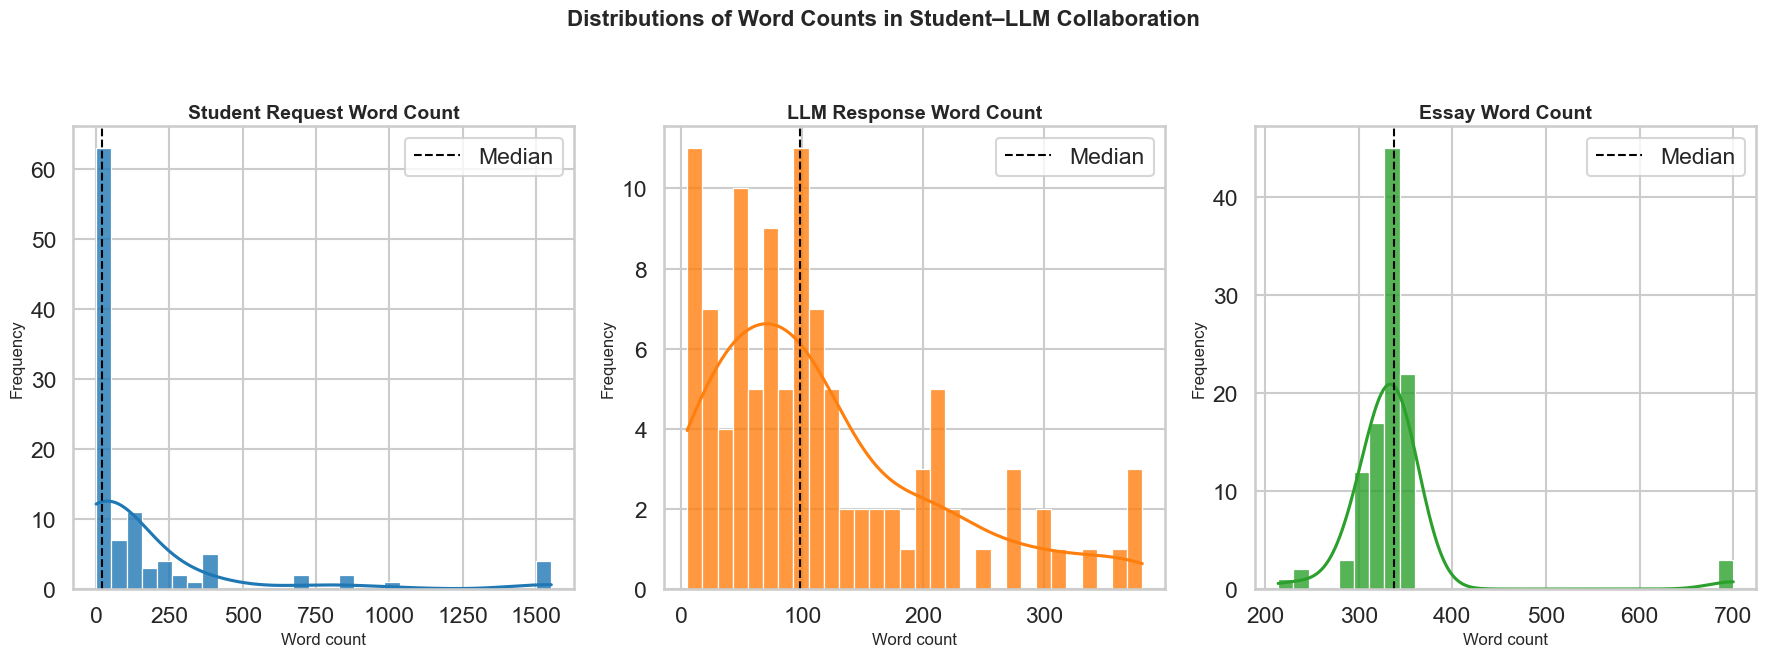

In [243]:
# Apply a seaborn theme for readability
sns.set_theme(style="whitegrid", context="talk")

# Plot the figure size
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)

# Define histogram style parameters
hist_kws = dict(bins=30, edgecolor="white", alpha=0.8)

# Plot Student requests
sns.histplot(
    merged_data['request_word_count'],
    kde=True,
    color="#1f77b4",
    ax=axes[0],
    **hist_kws
)
axes[0].set_title("Student Request Word Count", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Word count", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].axvline(
    merged_data['request_word_count'].median(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Median"
)
axes[0].legend()

# Plot LLM responses
sns.histplot(
    merged_data['response_word_count'],
    kde=True,
    color="#ff7f0e",
    ax=axes[1],
    **hist_kws
)
axes[1].set_title("LLM Response Word Count", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Word count", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].axvline(
    merged_data['response_word_count'].median(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Median"
)
axes[1].legend()

# Plot Essays
sns.histplot(
    merged_data['essay_word_count'],
    kde=True,
    color="#2ca02c",
    ax=axes[2],
    **hist_kws
)
axes[2].set_title("Essay Word Count", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Word count", fontsize=12)
axes[2].set_ylabel("Frequency", fontsize=12)
axes[2].axvline(
    merged_data['essay_word_count'].median(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Median"
)
axes[2].legend()

# Set title and adjust fonts
fig.suptitle("Distributions of Word Counts in Student–LLM Collaboration", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


- Student requests (left plot)
Most students’ requests contain fewer words, as shown by the big spike around 0-50, suggesting that many interactions started with minimal prompts.
But the right tail at around 1500 words shows that few students enter queries with long texts into the LLM.
- LLM responses (middle plot)
Responses cluster around a moderate length of around 50–150 words, with fewer extremely short or extremely long answers.
This suggests the LLM tends to provide consistently sized, reasonably elaborate replies, regardless of how short many student prompts are. This can be read as the LLM trying to “fill in” context and support students even when they contribute little.
The right tail (200–350+ words) indicates that in some interactions, the LLM produces quite extended guidance.
- Essays (right plot)
Essay word counts are much more concentrated, mostly in the 250–400 range, with an outlier near 700.

- Overall, students begin the interaction with mostly short prompts, and occasionally long ones, and in juxtaposing those with the LLM result, which seem relatively stable in length and occasionally higher, we can decipher that many students may not initially articulate rich, detailed questions, which could limit collaboration quality unless the LLM compensates in ways that make it the main driver of elaboration.


Measure interactions per student

In [244]:
# Group conversations by student_id and count interactions per student.
# This creates a key collaboration-quality indicator: how many times each student
# engages with the LLM. More interactions could proxy for deeper engagement,
# and reliance on the LLM as a thinking partner.

interactions_per_student = merged_data.groupby('student_id').size().reset_index(name='number_of_interactions')
print("Number of Interactions per Student:")
print(interactions_per_student.describe())

display(interactions_per_student.head())

Number of Interactions per Student:
       number_of_interactions
count               16.000000
mean                 6.562500
std                  7.597971
min                  1.000000
25%                  1.000000
50%                  2.500000
75%                 12.500000
max                 21.000000


,student_id,number_of_interactions
0,leaps_user108,3
1,leaps_user111,1
2,leaps_user114,1
3,leaps_user117,2
4,leaps_user129,3


Time series distribution of interactions by hour of day

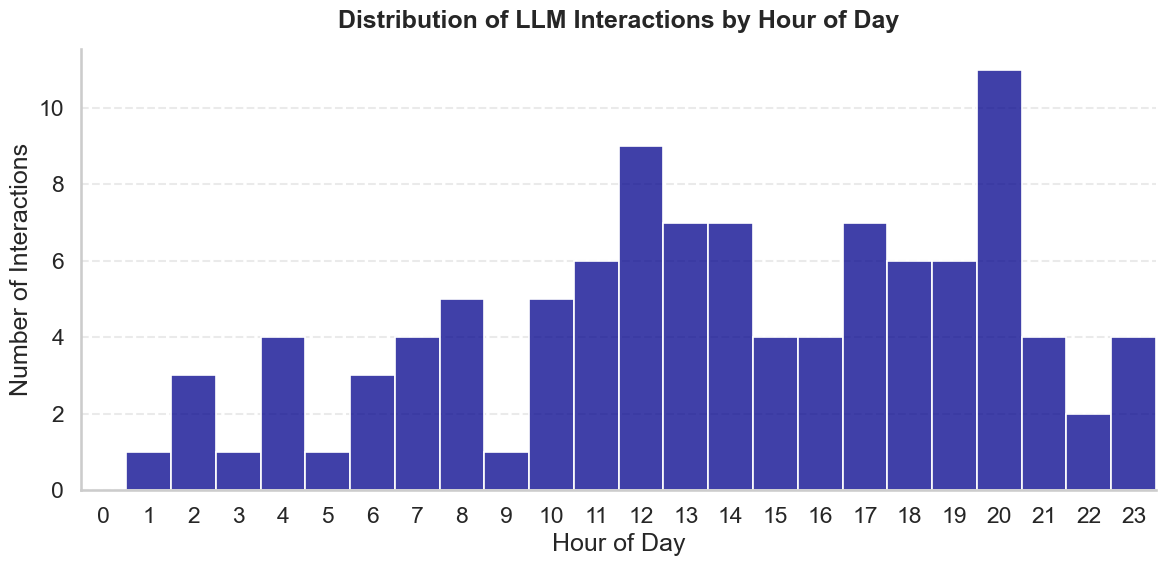

In [245]:
# Visualise the distribution of conversation hours across the day.
# This reveals temporal patterns in LLM usage, which cound indicate peak productivity times

# Set a theme
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 6))

sns.histplot(
    merged_data['hour'],
    bins=np.arange(-0.5, 24.5, 1),   # align bins exactly with hours
    color="#00008B",
    edgecolor="white",
    linewidth=1.2
)

plt.title("Distribution of LLM Interactions by Hour of Day", pad=15, weight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Interactions")

plt.xticks(range(0, 24))
plt.xlim(-0.5, 23.5)

# subtle grid
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.grid(axis='x', visible=False)

sns.despine()
plt.tight_layout()

plt.show()

The histogram shows distinct peaks at 12 PM and 8 PM, where the collaboration between students and LLMs is most pronounced. On the flip side, the spread in collaboratory hours between 10 AM and 2 PM is popular when students are freshly engaged in academic work, such as outlining essays, following up with classroom instructions, or seeking guidance. We could safely build a hypothesis that the activities represented between 5 PM and 8 PM are most likely consistent with the periods when students are engaged with assignments or preparing for a test, suggesting high-quality collaboration with LLM.

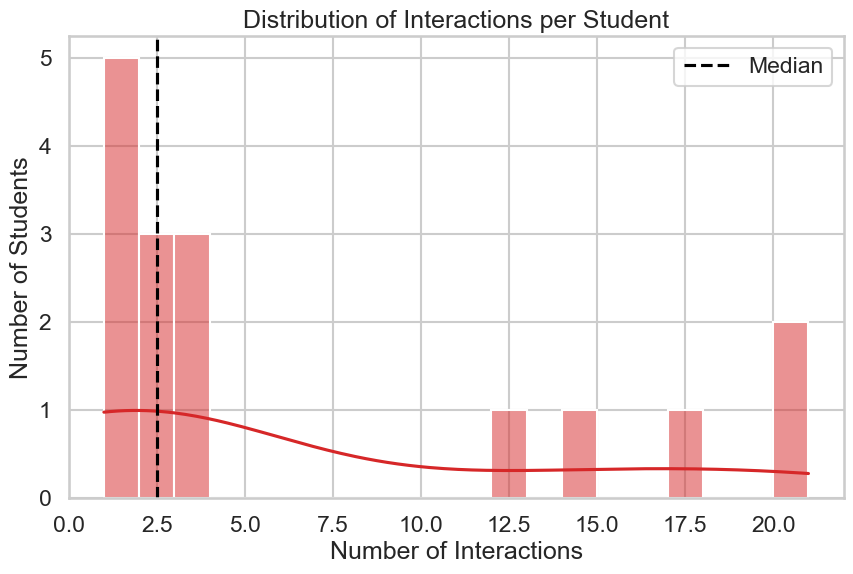

In [246]:
# Now, peek into the interaction distribution per student
plt.figure(figsize=(10, 6))
sns.histplot(interactions_per_student['number_of_interactions'], bins=20, kde=True, color="#d62728")
plt.title('Distribution of Interactions per Student')
plt.xlabel('Number of Interactions')
plt.ylabel('Number of Students')
plt.axvline(interactions_per_student['number_of_interactions'].median(), color="black", linestyle="--", label="Median")
plt.legend()
plt.show()


- The majority of students peak at 1–3 interactions, and from the small number of interactions, most of them use the LLM very sparingly.
- The median around 3–4 interactions (dashed line) shows that half the students never exceed this low threshold, suggesting that transactional use holds dominance over iterative collaboration.
- The long right tail beyond 17+ interactions shows that a small minority of students engage heavily, potentially representing deep, iterative collaboration where they refine ideas over multiple turns.


Run a segmentaton analysis based on the above histogram distribution

In [247]:
# Segment the categories of students based on their engagement levels

interactions_per_student['engagement_level'] = pd.cut(
    interactions_per_student['number_of_interactions'],
    bins=[0, 4, 12, float('inf')],
    labels=['Low', 'Medium', 'High']
)


In [248]:
# Display the numbers of engagement levels from each category

interactions_per_student['engagement_level'].value_counts()

engagement_level
Low       11
High       4
Medium     1
Name: count, dtype: int64

Explore the collaboration qualty indicators responsible for the segregation above

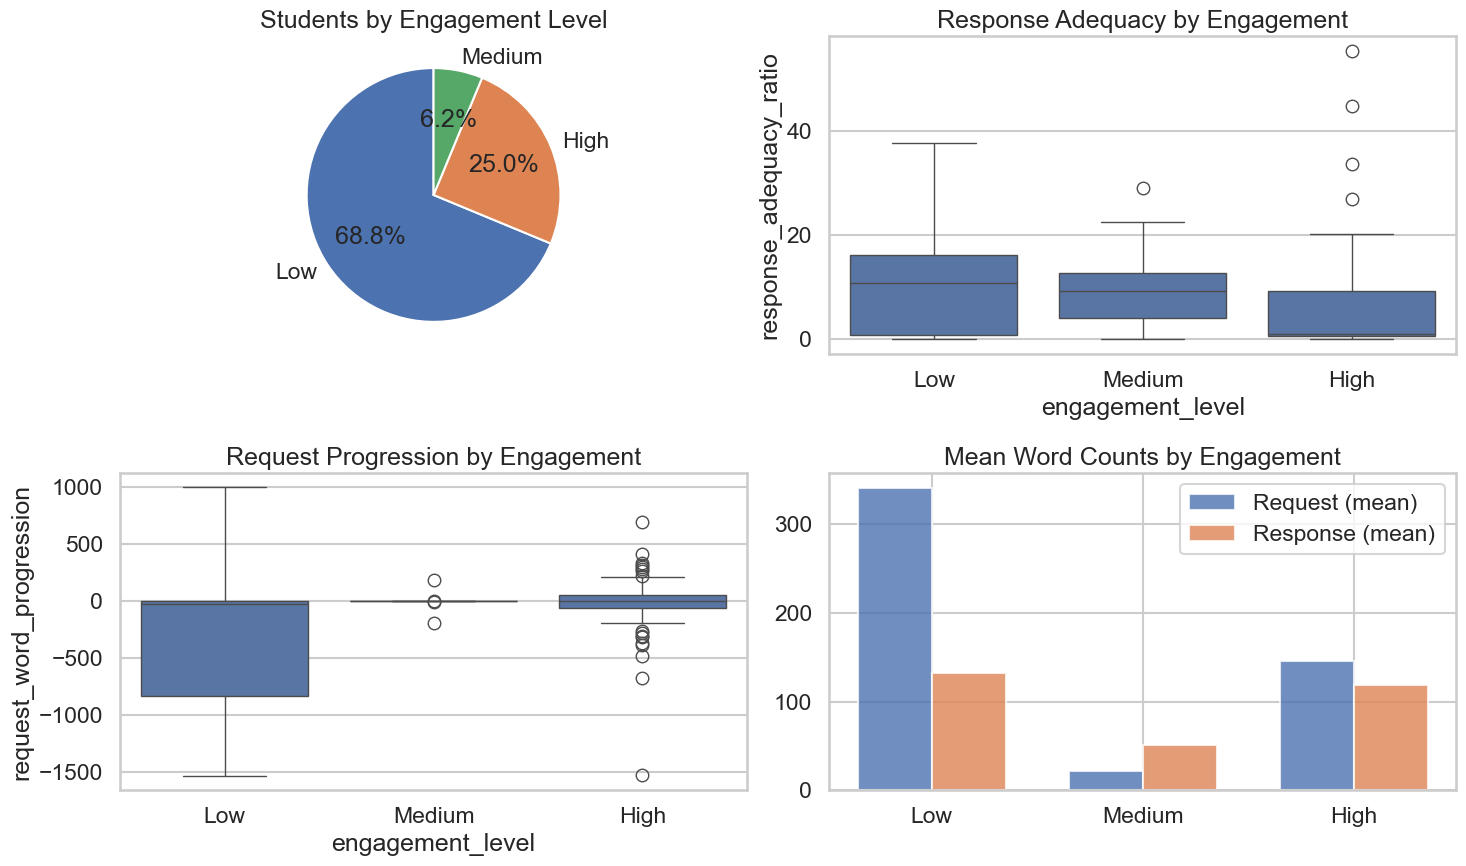

In [249]:

# Convert number_of_interactions to numeric datatype
interactions_per_student['number_of_interactions'] = pd.to_numeric(
    interactions_per_student['number_of_interactions'], errors='coerce'
)

# 3. Merge with the conversions_data
merged_data = merged_data.merge(
    interactions_per_student[['student_id', 'number_of_interactions', 'engagement_level']],
    on='student_id', how='left', suffixes=('', '_new')
)

# KEY COLLABORATION QUALITY INDICATORS

# Check if LLM provides "enough" response relative to student input
merged_data['response_adequacy_ratio'] = (
    merged_data['response_word_count'] / merged_data['request_word_count'].replace(0, 1)
)

# Enforce sorted progression by student and timestamp
merged_data = merged_data.sort_values(['student_id', 'timestamp'])

# Compute the progression of requests
merged_data['request_word_progression'] = merged_data.groupby('student_id')['request_word_count'].diff()

# Perform aggregation to Creates student-level summary stats from conversation-level data
student_collaboration_stats = merged_data.groupby(['student_id', 'engagement_level']).agg({
    'number_of_interactions': 'first',
    'request_word_count': ['mean', 'std'],
    'response_word_count': ['mean', 'std'],
    'response_adequacy_ratio': 'mean',
    'request_word_progression': 'mean'
}).reset_index()

# Flatten multi-level columns
student_collaboration_stats.columns = [
    '_'.join(col).strip().rstrip('_') if col[1] != '' else col[0]
    for col in student_collaboration_stats.columns
]


# VISUALIZATIONS

# Make a plot to show 4 key perspectives on collaboration quality
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# Plot the pie chart to show the proportion of students in each engagement category at a glance
engagement_counts = interactions_per_student['engagement_level'].value_counts()
axes[0,0].pie(engagement_counts.values, labels=engagement_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Students by Engagement Level')

# Response adequacy by engagement

# Plot boxplot to compare LLM response balance across engagement levels
# Plot histogram if only 1 engagement level exists.

if len(merged_data['engagement_level'].unique()) > 1:
    sns.boxplot(data=merged_data, x='engagement_level', y='response_adequacy_ratio', ax=axes[0,1])
    axes[0,1].set_title('Response Adequacy by Engagement')
else:
    axes[0,1].hist(merged_data['response_adequacy_ratio'], bins=30, alpha=0.7, color='skyblue')
    axes[0,1].set_title('Response Adequacy Distribution')

# Request progression
sns.boxplot(data=merged_data.dropna(subset=['request_word_progression']),
            x='engagement_level', y='request_word_progression', ax=axes[1,0])
axes[1,0].set_title('Request Progression by Engagement')

# Word count comparison to compares typical message lengths between students vs LLM by engagement
if 'request_word_count_mean' in student_collaboration_stats.columns:
    comparison_data = student_collaboration_stats.groupby(
        'engagement_level'
    )[['request_word_count_mean','response_word_count_mean']].mean().reset_index()
    x = np.arange(len(comparison_data))
    width = 0.35
    axes[1,1].bar(x - width/2, comparison_data['request_word_count_mean'], width,
                  label='Request (mean)', alpha=0.8)
    axes[1,1].bar(x + width/2, comparison_data['response_word_count_mean'], width,
                  label='Response (mean)', alpha=0.8)
    axes[1,1].set_title('Mean Word Counts by Engagement')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(comparison_data['engagement_level'])
    axes[1,1].legend()

plt.tight_layout()
plt.show()


- Engagement Distribution Analysis:
From the pie chart distribution, 68.8% of students fall in the low-engagement cluster (1-4 interactions), representing transactional query behavior. 25% form the high-engagement tail (12+ interactions), exhibiting iterative refinement patterns, while only 6.2% remain neutral.."

- Response Adequacy Modeling:
From the “Response adequacy by engagement” metric, LLM response volume exceeds student input by 2-40 times. High-engagement students show tighter variance in this ratio, indicating more stable LLM contribution as dialogue matures.
- Prompt Evolution Signal:
From the boxplot on the bottom-left, "Request word progression by Engagement” reveals statistically significant divergence with high-engagement as high as 1000 words demonstrating the strongest collaboration quality indicator. This means that the 25% who keep coming back improved their query requests over time.
- Dialogue Structure Comparison:
The histogram on the bottom-right reveals that casual users most likely paste long text once and get short replies with little or no engagement. However, the 25% power users ask short questions, get detailed LLM responses, then ask again for actual conversations."


Measure the correspondence between the 4 indicators and the Essay output

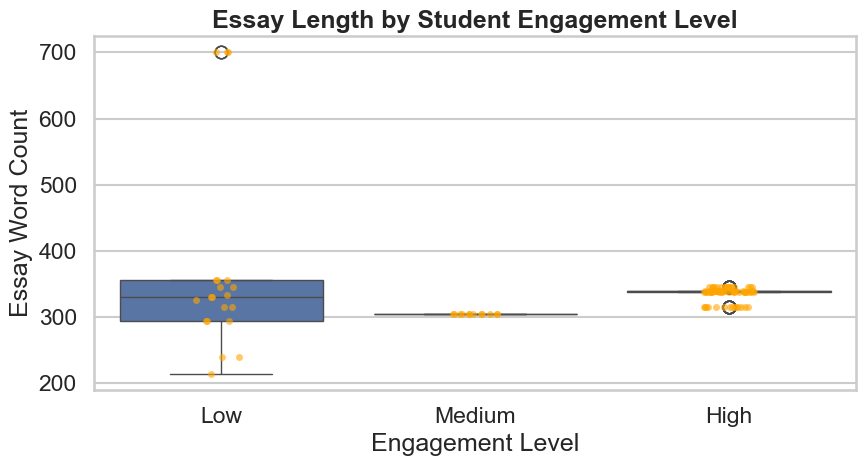

In [250]:
# Prepare the plot layout
plt.figure(figsize=(9, 5))
sns.boxplot(data=merged_data, x='engagement_level', y='essay_word_count')

sns.stripplot(
    data=merged_data,
    x='engagement_level',
    y='essay_word_count',
    color='orange',
    alpha=0.6
)

plt.title('Essay Length by Student Engagement Level', fontweight='bold')
plt.ylabel('Essay Word Count')
plt.xlabel('Engagement Level')

plt.tight_layout()
plt.show()

For students characterized with low engagement, their essay word-count tends to be lower than that of students who continually engage with LLMs. This shows that student output can be safely measured as a determinant of the degree of their engagement with LLMs
